# Analytics Module
The Analytics module provides descriptive statistics on content data, evidence data and model evaluations 

In [1]:
# reloads modules automatically before entering the execution of code
%load_ext autoreload
%autoreload 2

# third parties imports
import numpy as np 
import pandas as pd
# -- add new imports here --

# local imports
from constants import Constant as C
from loaders import load_ratings
from loaders import load_items

# 1 - Content analytics
Explore and perform descriptive statistics on content data

In [2]:
# -- load the items and display the Dataframe
df_items = load_items()
display(df_items)

,title,genres
movieId,,
1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,Jumanji (1995),Adventure|Children|Fantasy
3,Grumpier Old Men (1995),Comedy|Romance
4,Waiting to Exhale (1995),Comedy|Drama|Romance
5,Father of the Bride Part II (1995),Comedy
...,...,...
162672,Mohenjo Daro (2016),Adventure|Drama|Romance
163056,Shin Godzilla (2016),Action|Adventure|Fantasy|Sci-Fi
163949,The Beatles: Eight Days a Week - The Touring Y...,Documentary


In [3]:
# -- display relevant informations that can be extracted from the dataset
n_movies = str(df_items.shape[0])
print("Number of movies:" + n_movies)

Number of movies:9125


# 2 - Evidence analytics
Explore and perform descriptive statistics on evidence data

In [4]:
# -- load the items and display the Dataframe
df_ratings = load_ratings()
display(df_ratings)

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205
...,...,...,...,...
99999,671,6268,2.5,1065579370
100000,671,6269,4.0,1065149201
100001,671,6365,4.0,1070940363
100002,671,6385,2.5,1070979663


In [ ]:
# -- display relevant informations that can be extracted from the dataset
n_ratings = str(df_ratings.shape[0])
print("a) The total number of ratings : "+str(n_ratings)) 
print()
#Find unique users 
n_unique_users = str(df_ratings.userId.nunique())
print("b) The number of unique users : " + n_unique_users)
print()
#Find unique movies
n_unique_movies = str(df_ratings.movieId.nunique())
print("c) The Number of unique movies : " + n_unique_movies)
print()
#Number of ratings per movie for the most rated movies
n_most_rated_movie = (df_ratings.groupby('movieId').size())
n_most_rated_movie_df = n_most_rated_movie.reset_index()
n_most_rated_movie_df.columns = ['movieId', 'number of ratings']

print("d) the number of ratings of the most rated movie(s)")
display(n_most_rated_movie_df.sort_values(by='number of ratings', ascending=False).head(5))
print()
#Number of ratings per movie for the less rated movies
print("e) the number of ratings of the less rated movie(s)")
display(n_most_rated_movie_df.sort_values(by='number of ratings', ascending=True).head(5))
print()
# all the possible ratings values
print("f) # all the possible ratings values")
ratings = df_ratings.rating.unique()
ratings.sort()
for i in ratings :
    print(i)
# -- find the number of movies that were not rated at all
print()
print("g) the number of movies that were not rated at all : " + str(int(n_movies) - int(n_unique_movies)))






a) The total number of ratings : 100004

b) The number of unique users : 671

c) The Number of unique movies : 9066

d) the number of ratings of the most rated movie(s)


,movieId,number of ratings
321,356,341
266,296,324
284,318,311
525,593,304
232,260,291



e) the number of ratings of the less rated movie(s)


,movieId,number of ratings
9065,163949,1
5791,26485,1
5790,26480,1
5788,26471,1
5787,26467,1



f) # all the possible ratings values
0.5
1.0
1.5
2.0
2.5
3.0
3.5
4.0
4.5
5.0

g) the number of movies that were not rated at all : 59


# 3 - Long-Tail property

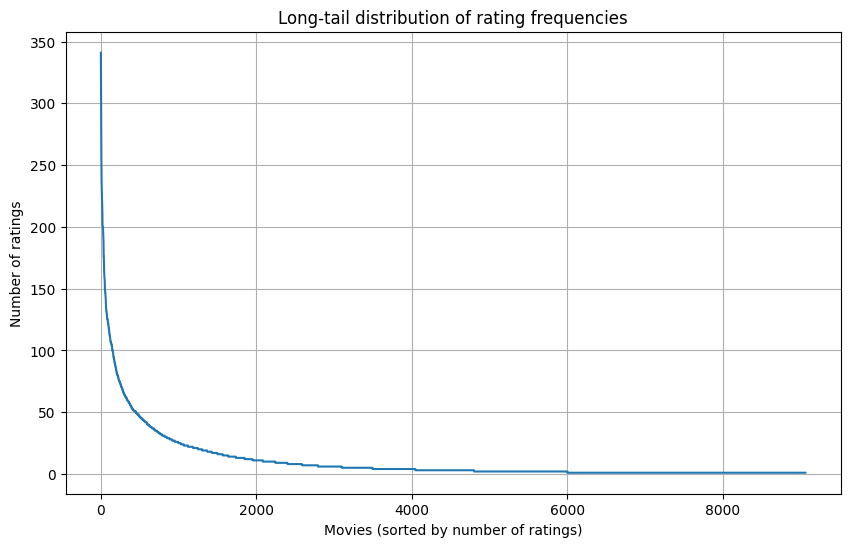

In [7]:
import matplotlib.pyplot as plt
# distribution des notes
rating_counts = df_ratings['movieId'].value_counts()


rating_counts_sorted = rating_counts.sort_values(ascending=False).reset_index(drop=True)
plt.figure(figsize=(10, 6))
plt.plot(rating_counts_sorted.values)
plt.title('Long-tail distribution of rating frequencies')
plt.xlabel('Movies (sorted by number of ratings)')
plt.ylabel('Number of ratings')
plt.grid(True)
plt.show()


Sparsity-matrix

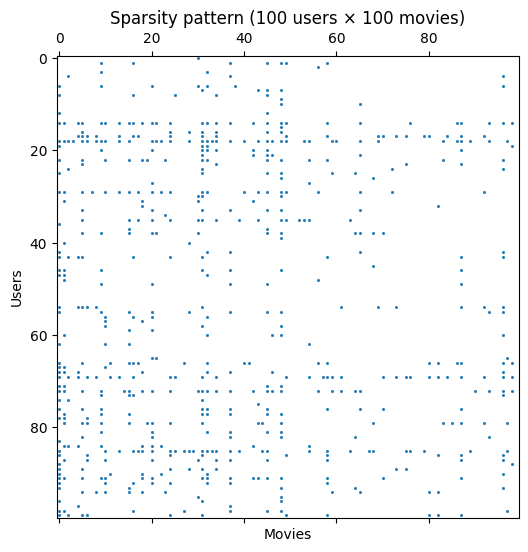

Sparsity: 0.9835608583913366


In [8]:
from scipy.sparse import csr_matrix

def create_X(df):
    """
    Generates a sparse matrix from ratings dataframe.

    Args:
        df: pandas dataframe containing 3 columns (userId, movieId, rating)

    Returns:
        X: sparse matrix
        user_mapper: dict that maps user id's to user indices
        user_inv_mapper: dict that maps user indices to user id's
        movie_mapper: dict that maps movie id's to movie indices
        movie_inv_mapper: dict that maps movie indices to movie id's
    """
    M = df['userId'].nunique()
    N = df['movieId'].nunique()

    user_mapper = dict(zip(np.unique(df["userId"]), list(range(M))))
    movie_mapper = dict(zip(np.unique(df["movieId"]), list(range(N))))

    user_inv_mapper = dict(zip(list(range(M)), np.unique(df["userId"])))
    movie_inv_mapper = dict(zip(list(range(N)), np.unique(df["movieId"])))

    user_index = [user_mapper[i] for i in df['userId']]
    item_index = [movie_mapper[i] for i in df['movieId']]

    X = csr_matrix((df["rating"], (user_index,item_index)), shape=(M,N))

    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_X(df_ratings)
#affiche la matrice sparse
plt.figure(figsize=(6, 6))
plt.spy(X[:100, :100], markersize=1)
plt.title("Sparsity pattern (100 users × 100 movies)")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()
# calcul de la sparsité de la matrice
sparsity = 1.0 - (X.count_nonzero() / (X.shape[0] * X.shape[1]))
print("Sparsity: " + str(sparsity))